# Model Training Notebook



In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import string
import nltk
nltk.data.path.append(r"C:\Users\slimc\Desktop\FakeNews\nltk_data")
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import warnings
warnings.filterwarnings("ignore")

import os

# Désactiver le GPU (comme dans Kaggle)
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# --- Nouveau chemin local ---
data_path = r"C:\Users\slimc\Desktop\FakeNews\data"

# Pour lister les fichiers
for dirname, _, filenames in os.walk(data_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

C:\Users\slimc\Desktop\FakeNews\data\dataset.py
C:\Users\slimc\Desktop\FakeNews\data\data_exploration.py
C:\Users\slimc\Desktop\FakeNews\data\Data_Understanding.ipynb
C:\Users\slimc\Desktop\FakeNews\data\Fake.csv
C:\Users\slimc\Desktop\FakeNews\data\preprocessing.py
C:\Users\slimc\Desktop\FakeNews\data\True.csv


In [2]:
true_df = pd.read_csv(os.path.join(data_path, "True.csv"))
fake_df = pd.read_csv(os.path.join(data_path, "Fake.csv"))

In [3]:
true_df["label"] = 1  # Real news
fake_df["label"] = 0  # Fake news

In [4]:
df = pd.concat([true_df, fake_df], ignore_index=True)


# Model Training Notebook


In [5]:
df = df[["title", "text", "label"]]

In [6]:
df["content"] = df["title"] + " " + df["text"]

In [7]:
df.dropna(inplace=True)

In [8]:
df = df.sample(frac=1, random_state=537).reset_index(drop=True)

In [9]:
df = df[["content", "label"]]

In [10]:
df.isnull().sum()

content    0
label      0
dtype: int64

# Text Cleaning & EDA

In [11]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Tokenize
    words = nltk.word_tokenize(text)
    # Remove stopwords and lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words and word.isalpha()]
    return " ".join(words)

In [12]:
df["clean_text"] = df["content"].apply(clean_text)

# Deep Learning Model with LSTM

Text Tokenization & Padding

In [13]:
MAX_VOCAB = 10000       # max number of words in the vocabulary
MAX_LEN = 300   

In [14]:
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(df["clean_text"])

In [15]:
sequences = tokenizer.texts_to_sequences(df["clean_text"])

In [16]:
padded_sequences = pad_sequences(sequences, maxlen=MAX_LEN, padding="post", truncating="post")

In [17]:
labels = df["label"].values

Train-Test Split

In [18]:
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    padded_sequences, labels, test_size=0.2, random_state=537)

Define the LSTM Model

In [19]:
model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=128, input_length=MAX_LEN),
    LSTM(128, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # binary classification
])

In [20]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [21]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 300, 128)          1280000   
                                                                 
 lstm (LSTM)                 (None, 128)               131584    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                                 
Total params: 1,419,905
Trainable params: 1,419,905
Non-

Train the Model

In [22]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger

# Folder to store checkpoints
checkpoint_path = "best_lstm_model.h5"

callbacks = [
    # 1) Stop training early if validation loss stops improving
    EarlyStopping(
        monitor='val_loss',
        patience=2,          # number of epochs with no improvement
        restore_best_weights=True
    ),

    # 2) Save the best model based on validation accuracy
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),

    # 3) Reduce learning rate if validation loss stagnates
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=1,
        min_lr=1e-6,
        verbose=1
    ),

    # 4) Save metrics to a CSV file
    CSVLogger("training_log.csv", append=True)
]


In [26]:
history = model.fit(
    X_train_dl, y_train_dl,
    validation_data=(X_test_dl, y_test_dl),
    epochs=15,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/15
141/141 [==============================] - ETA: 0s - loss: 0.5069 - accuracy: 0.7354
Epoch 1: val_accuracy improved from -inf to 0.89566, saving model to best_lstm_model.h5
141/141 [==============================] - 170s 1s/step - loss: 0.5069 - accuracy: 0.7354 - val_loss: 0.3010 - val_accuracy: 0.8957 - lr: 0.0010
Epoch 2/15
141/141 [==============================] - ETA: 0s - loss: 0.3291 - accuracy: 0.8942
Epoch 2: val_accuracy did not improve from 0.89566

Epoch 2: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
141/141 [==============================] - 189s 1s/step - loss: 0.3291 - accuracy: 0.8942 - val_loss: 0.3423 - val_accuracy: 0.8777 - lr: 0.0010
Epoch 3/15
141/141 [==============================] - ETA: 0s - loss: 0.4382 - accuracy: 0.8310
Epoch 3: val_accuracy improved from 0.89566 to 0.92105, saving model to best_lstm_model.h5

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
141/141 [===========================

Visualize Accuracy and Loss

281/281 [==============================] - 12s 40ms/step


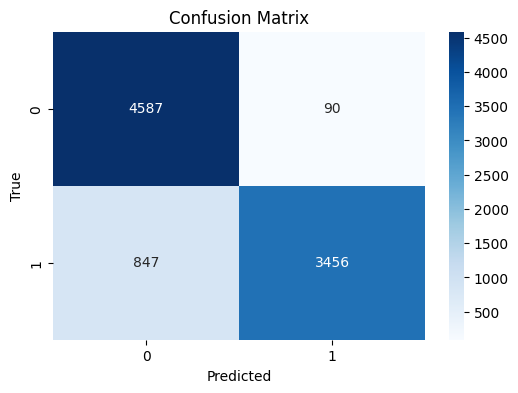

              precision    recall  f1-score   support

           0       0.84      0.98      0.91      4677
           1       0.97      0.80      0.88      4303

    accuracy                           0.90      8980
   macro avg       0.91      0.89      0.89      8980
weighted avg       0.91      0.90      0.89      8980



In [30]:
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Load the best model
best_model = load_model("best_lstm_model.h5")

# Predictions
y_pred = (best_model.predict(X_test_dl) > 0.5).astype("int32")

# Confusion Matrix
cm = confusion_matrix(y_test_dl, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_test_dl, y_pred))


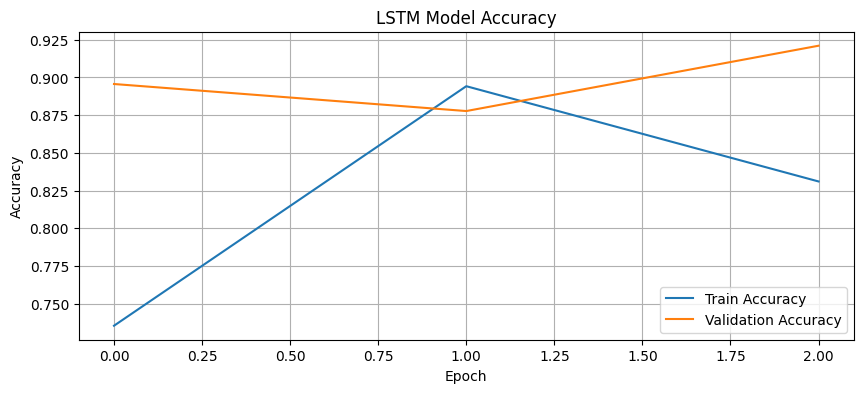

In [27]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.title("LSTM Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Deep Learning Model with BILSTM

Tokenization & Padding


In [31]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB = 10000     # vocabulary size
MAX_LEN = 300         # max sequence length

# Initialize tokenizer
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(df["clean_text"])

# Convert text → sequences
sequences = tokenizer.texts_to_sequences(df["clean_text"])

# Pad sequences
padded_sequences = pad_sequences(
    sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

labels = df["label"].values

Train-Test Split

In [32]:
from sklearn.model_selection import train_test_split

x_train_dl, x_test_dl, y_train_dl, y_test_dl = train_test_split(
    padded_sequences,
    labels,
    test_size=0.2,
    random_state=537
)


Build the BiLSTM Model

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

model_bilstm = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=128, input_length=MAX_LEN),
    
    Bidirectional(LSTM(128, return_sequences=False)),
    
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    Dropout(0.2),
    
    Dense(1, activation='sigmoid')   # binary classification
])

model_bilstm.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model_bilstm.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 300, 128)          1280000   
                                                                 
 bidirectional (Bidirectiona  (None, 256)              263168    
 l)                                                              
                                                                 
 dropout_2 (Dropout)         (None, 256)               0         
                                                                 
 dense_2 (Dense)             (None, 64)                16448     
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                 65        
                                                      

Callbacks (Best Model, EarlyStop, LR Scheduler)

In [34]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger

checkpoint_path = "best_bilstm_model.h5"

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=1,
        min_lr=1e-6,
        verbose=1
    ),
    
    CSVLogger("bilstm_training_log.csv", append=True)
]


Train the BiLSTM Model

In [ ]:
history_bilstm = model_bilstm.fit(
    x_train_dl, y_train_dl,
    validation_data=(x_test_dl, y_test_dl),
    epochs=15,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/15
 37/141 [======>.......................] - ETA: 5:41 - loss: 0.4171 - accuracy: 0.8208